Nama: Herlinasari\
NIM: 2430109040004\
Mata Kuliah: Analisis Regresi\
Dosen Pengampu: Khusnia Nurul Khikmah, M.Si.

# **Tugas 1**

In [50]:
import numpy as np
from scipy.stats import pearsonr
import pandas as pd
import matplotlib.pyplot as plt


Data yang digunakan

In [52]:
# Data
df = pd.read_csv('business_ c.csv')
df.head()
df.tail()
print(df.head())
print(df.tail())
variabel_x1 = df['Advertising_Budget']
variabel_x2 = df['Production_Cost']
variabel_x3 = df['Customer_Satisfaction']
variabel_y = df['Sales_Revenue']

   Advertising_Budget  Sales_Revenue  Production_Cost  Customer_Satisfaction
0           43.708611     682.969638       384.704577              40.657188
1           95.564288    1583.557981       742.956775              86.985455
2           75.879455    1214.225729       642.474928              60.871307
3           63.879264     912.036661       577.556323              41.834744
4           24.041678     288.751991       241.562352              16.737460
     Advertising_Budget  Sales_Revenue  Production_Cost  Customer_Satisfaction
495           41.801701     584.556006       305.138920              37.305714
496           62.529050     898.780596       629.670893              38.767285
497           16.996117     338.474630        99.626043              13.961410
498           97.695533    1519.984310       826.089984              75.867187
499           98.758967    1629.121091       808.029291              82.856860


Koefisien Korelasi Pearson

In [53]:

# Menentukan Variabel
variabel_y = df['Sales_Revenue']

variabel_x_list = [
    'Advertising_Budget',
    'Production_Cost',
    'Customer_Satisfaction']

# Simpan hasil korelasi
hasil_korelasi = {}
hasil_pvalue = {}
alpha = 0.05

for nama_x in variabel_x_list:
    variabel_x = df[nama_x]
    korelasi_pearson, p_value = pearsonr(variabel_x, variabel_y)

    # hasil korelasi dan p-value
    hasil_korelasi[nama_x] = korelasi_pearson
    hasil_pvalue[nama_x] = p_value

    print(f"\nKorelasi antara {nama_x} dan Sales_Revenue")
    print(f"Koefisien Korelasi Pearson: {korelasi_pearson:.3f}")
    print(f"P-value: {p_value:.3f}")

    # Interpretasi
    if korelasi_pearson > 0.8:
        interpretasi = "Korelasi sangat kuat positif"
    elif korelasi_pearson > 0.6:
        interpretasi = "Korelasi kuat positif"
    elif korelasi_pearson > 0.4:
        interpretasi = "Korelasi sedang positif"
    elif korelasi_pearson > 0.2:
        interpretasi = "Korelasi lemah positif"
    elif korelasi_pearson > 0:
        interpretasi = "Korelasi sangat lemah positif"
    elif korelasi_pearson < -0.8:
        interpretasi = "Korelasi sangat kuat negatif"
    elif korelasi_pearson < -0.6:
        interpretasi = "Korelasi kuat negatif"
    elif korelasi_pearson < -0.4:
        interpretasi = "Korelasi sedang negatif"
    elif korelasi_pearson < -0.2:
        interpretasi = "Korelasi lemah negatif"
    elif korelasi_pearson < 0:
        interpretasi = "Korelasi sangat lemah negatif"
    else:
        interpretasi = "Tidak ada korelasi linier"

    # Keputusan hipotesis
    if p_value < alpha:
        keputusan = "Tolak H0 (Signifikan)"
    else:
        keputusan = "Gagal Tolak H0 (Tidak signifikan)"

    print("Interpretasi:", interpretasi)
    print("Keputusan:", keputusan)

# Menentukan Korelasi Terkuat
variabel_terkuat = max(hasil_korelasi, key=lambda k: abs(hasil_korelasi[k]))
nilai_terkuat = hasil_korelasi[variabel_terkuat]
pvalue_terkuat = hasil_pvalue[variabel_terkuat]

print("\n====================================")
print("Variabel dengan Korelasi Terkuat:")
print(f"{variabel_terkuat}")




Korelasi antara Advertising_Budget dan Sales_Revenue
Koefisien Korelasi Pearson: 0.981
P-value: 0.000
Interpretasi: Korelasi sangat kuat positif
Keputusan: Tolak H0 (Signifikan)

Korelasi antara Production_Cost dan Sales_Revenue
Koefisien Korelasi Pearson: 0.949
P-value: 0.000
Interpretasi: Korelasi sangat kuat positif
Keputusan: Tolak H0 (Signifikan)

Korelasi antara Customer_Satisfaction dan Sales_Revenue
Koefisien Korelasi Pearson: 0.973
P-value: 0.000
Interpretasi: Korelasi sangat kuat positif
Keputusan: Tolak H0 (Signifikan)

Variabel dengan Korelasi Terkuat:
Advertising_Budget


Scatterplot korelasi paling kuat

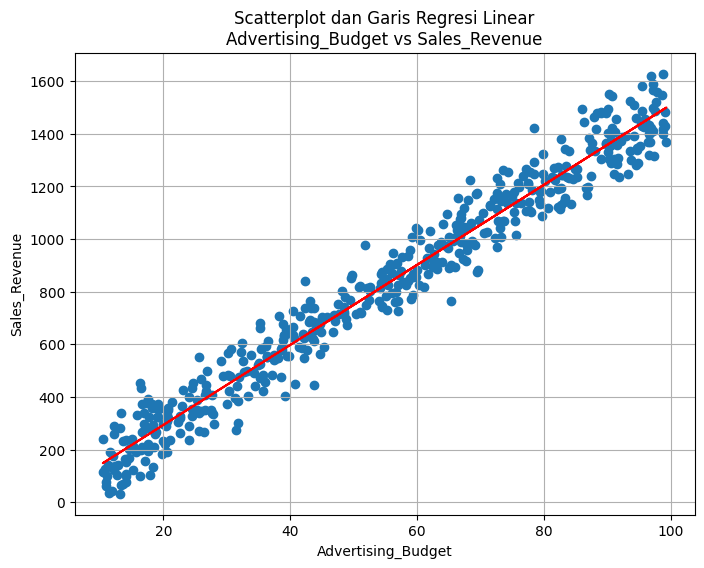

In [54]:
# Ambil data
x_terkuat = df[variabel_terkuat]
y = df['Sales_Revenue']

# Hitung koefisien regresi (y = mx + b)
m, b = np.polyfit(x_terkuat, y, 1)

# Buat scatterplot
plt.figure(figsize=(8,6))
plt.scatter(x_terkuat, y)

# Garis regresi
plt.plot(x_terkuat, m*x_terkuat + b, color='red')

# Label dan judul
plt.xlabel(variabel_terkuat)
plt.ylabel("Sales_Revenue")
plt.title(f'Scatterplot dan Garis Regresi Linear\n{variabel_terkuat} vs Sales_Revenue')
plt.grid(True)

plt.show()

Uji hipotesis korelasi terkuat

In [55]:
# Tetapkan tingkat signifikansi
alpha = 0.05

print("====================================")
print("Uji Hipotesis Korelasi Terkuat")
print(f"Variabel Terkuat: {variabel_terkuat}")
print(f"Koefisien Korelasi Pearson: {nilai_terkuat:.3f}")
print(f"P-value: {pvalue_terkuat:.3f}")
print(f"Tingkat Signifikansi (alpha): {alpha}")

# Uji hipotesis
if pvalue_terkuat < alpha:
    keputusan = "Tolak Hipotesis Nol (H0)"
    interpretasi_uji = (
        f"Ada bukti statistik yang cukup untuk menyimpulkan bahwa "
        f"{variabel_terkuat} memiliki hubungan linier yang signifikan "
        f"dengan Sales_Revenue."
    )
else:
    keputusan = "Gagal Menolak Hipotesis Nol (H0)"
    interpretasi_uji = (
        f"Tidak ada bukti statistik yang cukup untuk menyimpulkan bahwa "
        f"{variabel_terkuat} memiliki hubungan linier yang signifikan "
        f"dengan Sales_Revenue."
    )

print(f"\nKeputusan: {keputusan}")
print(f"Interpretasi Uji: {interpretasi_uji}")

Uji Hipotesis Korelasi Terkuat
Variabel Terkuat: Advertising_Budget
Koefisien Korelasi Pearson: 0.981
P-value: 0.000
Tingkat Signifikansi (alpha): 0.05

Keputusan: Tolak Hipotesis Nol (H0)
Interpretasi Uji: Ada bukti statistik yang cukup untuk menyimpulkan bahwa Advertising_Budget memiliki hubungan linier yang signifikan dengan Sales_Revenue.


# **Tugas 2**

Data yang digunakan

In [56]:
# Data
df = pd.read_csv('business sales.csv')
df.head()
df.tail()
print(df.head())
print(df.tail())
variabel_x = df['Advertising']
variabel_y = df['Sales_Revenue']

   Advertising  Sales_Revenue
0   110.540994     662.209476
1    57.198114     551.019879
2    49.490689     644.475782
3    91.670920     491.103329
4   113.530966     583.589563
     Advertising  Sales_Revenue
122    58.023624     560.301133
123    87.601320     599.137619
124   137.248478     561.992015
125   147.872015     617.262467
126    53.480468     499.464320


Koefisien Korelasi Person

In [57]:
# Hitung koefisien korelasi Pearson
korelasi_pearson, p_value = pearsonr(variabel_x, variabel_y)
print(f"\nKoefisien Korelasi Pearson antara Variabel X dan Variabel Y:\n{korelasi_pearson:.3f}")
# Interpretasi hasil
if korelasi_pearson > 0.8:
    interpretasi = "Korelasi sangat kuat positif"
elif korelasi_pearson > 0.6:
    interpretasi = "Korelasi kuat positif"
elif korelasi_pearson > 0.4:
    interpretasi = "Korelasi sedang positif"
elif korelasi_pearson > 0.2:
    interpretasi = "Korelasi lemah positif"
elif korelasi_pearson > 0:
    interpretasi = "Korelasi sangat lemah positif"
elif korelasi_pearson < -0.8:
    interpretasi = "Korelasi sangat kuat negatif"
elif korelasi_pearson < -0.6:
    interpretasi = "Korelasi kuat negatif"
elif korelasi_pearson < -0.4:
    interpretasi = "Korelasi sedang negatif"
elif korelasi_pearson < -0.2:
    interpretasi = "Korelasi lemah negatif"
elif korelasi_pearson < 0:
    interpretasi = "Korelasi sangat lemah negatif"
else:
    interpretasi = "Tidak ada korelasi linier (atau sangat mendekati nol)"
print(f"Interpretasi: {interpretasi}")


Koefisien Korelasi Pearson antara Variabel X dan Variabel Y:
0.385
Interpretasi: Korelasi lemah positif


Scatterplot

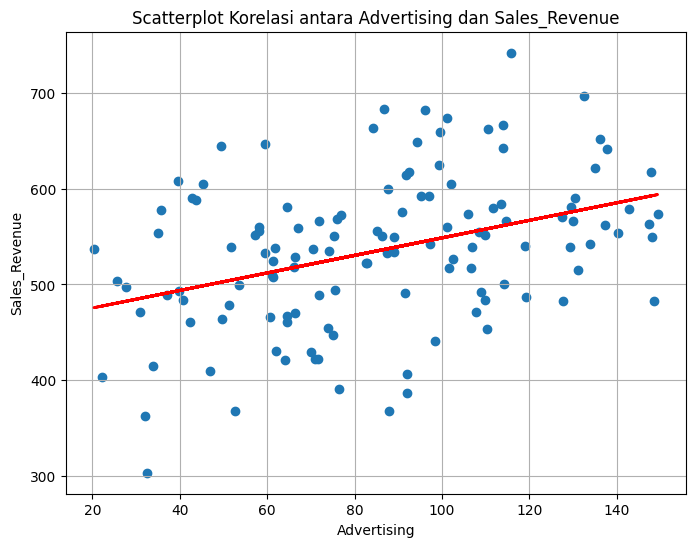

In [58]:
# Buat scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(variabel_x, variabel_y)

# Tambahkan label dan judul
plt.xlabel('Advertising')
plt.ylabel('Sales_Revenue')

m, b = np.polyfit(variabel_x, variabel_y, 1)
plt.plot(variabel_x, m*variabel_x + b, color='red', linewidth=2)

plt.title('Scatterplot Korelasi antara Advertising dan Sales_Revenue')
plt.grid(True)
# Tampilkan plot
plt.show()

Uji hipotesis korelasi

In [59]:
# Tetapkan tingkat signifikansi (alpha)
alpha = 0.05
print(f"Koefisien Korelasi Pearson: {korelasi_pearson:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"Tingkat Signifikansi (alpha): {alpha}")

# Lakukan uji hipotesis
if p_value < alpha:
  keputusan = "Tolak Hipotesis Nol (H0)"
  interpretasi_uji = "Ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara Advertising dan Sales Revenue pada populasi."
else:
  keputusan = "Gagal Menolak Hipotesis Nol (H0)"
  interpretasi_uji = "Tidak ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara Advertising dan Sales Revenue pada populasi."

print(f"\nKeputusan: {keputusan}")
print(f"Interpretasi Uji: {interpretasi_uji}")

Koefisien Korelasi Pearson: 0.385
P-value: 0.000
Tingkat Signifikansi (alpha): 0.05

Keputusan: Tolak Hipotesis Nol (H0)
Interpretasi Uji: Ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara Advertising dan Sales Revenue pada populasi.
